# MACE in Practice

This tutorial was originally made by Ioan Magdău, Ilyes Batatia and Will Baldwin (part of the MACE team at Cambridge), and simplified/modified by Seán Kavanagh for the purposes of the AMET MPhil Computational Techniques for Energy Materials course.

As discussed in our lectures, GPUs can be much faster for Molecular Dynamics and ML training/deployment. We can use GPUs in Colab by following these instructions:

**To activate the GPU, click on the down arrow in the top right of the editor, click on "Change runtime type" and select "T4 GPU" from the menu Hardware accelerator and save.
Then click on "Connect". If this doesn't work, change all "cuda" instances in the notebook to "cpu" (and use the slower CPU option instead).**

First we install the necessary Python packages to our notebook environment:

In [ ]:
!git clone https://github.com/SAM-Laboratory/AMET_Comp_Practical_MACE_Practice  # download our tutorial data
%cd AMET_Comp_Practical_MACE_Practice
!pip install mace-torch nglview ipywidgets rdkit pymatviz
!pip install git+https://github.com/imagdau/aseMolec@main

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 47.3/47.3 kB 2.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 55.6/55.6 kB 7.8 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 248.9/248.9 kB 12.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 69.0/69.0 kB 4.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 955.5/955.5 kB 34.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.9/9.9 MB 60.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.7/4.7 MB 37.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.3/49.3 kB 3.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 51.9/51.9 kB 2.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 332.3/332.3 kB 15.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 118.1/118.1 kB 6.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 962.5/962.5 kB 21.0 MB/s eta 0:00:00
   ━━━━

In this tutorial, you will learn how to fit and test a `MACE` model (Message Passing Neural Network), which is a highly accurate and efficient MLIP (Machine Learnt Interatomic Potential). The training/testing techniques we show here, however, are broadly applicable to all MLIPs. You can independently learn about MACE by studying the [original method paper](https://proceedings.neurips.cc/paper_files/paper/2022/file/4a36c3c51af11ed9f34615b81edb5bbc-Paper-Conference.pdf). MACE was developed by unifying the Atomic Cluster Expansion (ACE) approach with the Neural Equivariant Interatomic Potentials (NequIP). The mathematical formalism which unifies these methods is explained in the [accompaning paper](https://doi.org/10.48550/arXiv.2205.06643). Another [useful reference](https://doi.org/10.48550/arXiv.2305.14247) showcases the method's performance on published benchmark datasets. The [code implementation](https://github.com/ACEsuit/mace) is publically available and [here](https://mace-docs.readthedocs.io/en/latest/) you can find the documentation.

## Learning Objectives for today:

1. **Understanding the data**
2. **Fitting and testing MACE models**
3. **Running Molecular Dynamics**

## 1. Understanding the data

### 1.1 Diverse Molecular Conformations

Understanding the data is a crucial part of fitting an MLIP.
We can only ever expect our MLIP to be as good as the data it is trained on, meaning that it can reproduce the potential energy surface (PES) in regions where we have training data, but will fail in PES regions where we do not have data.

In this example, we will develop an MLIP for molecular liquids of carbonates. The data presented here is a subset from [this work](https://doi.org/10.1021/acs.jpcb.2c03746) and comprises a mixture of 6 different types of molecules: cyclic carbonates (Vinylene carbonate VC, Ethylene carbonate EC, Propylene carbonate PC) and linear carbonates (Dimethyl carbonate DMC, Ethyl Methyl Carbonate EMC, Diethyl carbonate DEC). Mixtures of these molecules in various formulations are used as solvents in Li-ion battery electrolytes.

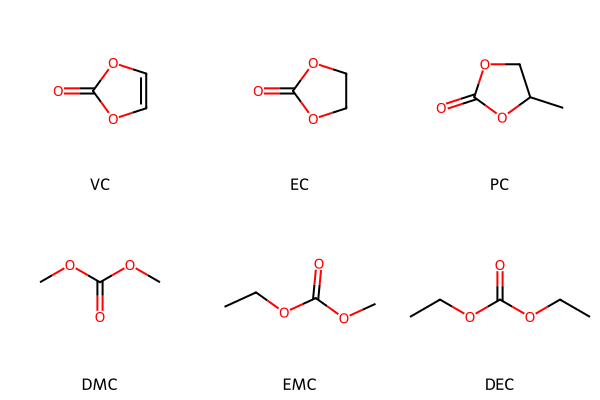

In [3]:
# this is some code to generate chemical diagrams of the molecules we're looking at
# you do not need to understand or modify this code!

from rdkit import Chem
from rdkit.Chem import Draw

# SMILES strings for each molecule
sm_dict = {
    'VC': 'c1coc(=O)o1',
    'EC': 'C1COC(=O)O1',
    'PC': 'CC1COC(=O)O1',
    'DMC': 'COC(=O)OC',
    'EMC': 'CCOC(=O)OC',
    'DEC': 'CCOC(=O)OCC'
}

Draw.MolsToGridImage([Chem.MolFromSmiles(sm_dict[mol]) for mol in sm_dict], legends=list(sm_dict.keys()))

For this tutorial, we prepared in advance a collection of molecular configurations (small subset from [this paper](https://doi.org/10.1021/acs.jpcb.2c03746)).
Let's look at the data!

The atomic configurations are stored in the [xyz](https://wiki.fysik.dtu.dk/ase/ase/io/formatoptions.html#extxyz) format and can be accessed using [ASE](https://wiki.fysik.dtu.dk/ase/index.html) as shown below:

In [76]:
from ase.io import read, write
import numpy as np

db = read('solvent_data_labelled.xyz', ':') # read in our dataset

print("Number of configs in database: ", len(db))
print("Number of atoms in each config: ", np.array([len(at) for at in db]))
print("Number of atoms in the smallest config: ", np.min([len(at) for at in db]))
print("Information stored in config.info: \n", db[10].info)
print("Information stored in config.arrays: \n", db[10].arrays)

Number of configs in database:  5003
Number of atoms in each config:  [ 1  1  1 ... 25 32 40]
Number of atoms in the smallest config:  1
Information stored in config.info: 
 {'Nmols': np.int64(3), 'Comp': 'DEC(2):EC(1)', 'REF_energy': np.float64(-2083.807425680116), 'REF_forces': array([[-1.2097741 , -2.39165186, -1.96402866],
       [ 0.07389339,  1.87891231,  2.12228931],
       [ 1.07191842,  2.09452527,  4.46538507],
       [ 0.98623913, -0.46858633, -1.97824022],
       [-0.81319099, -0.85065789, -3.67144715],
       [ 0.02161256,  0.42583203,  3.30068805],
       [ 0.13114651,  0.64504394,  1.715764  ],
       [-0.46296685,  1.07036558, -0.26466142],
       [ 1.84082445, -1.74825154, -0.32262755],
       [ 0.45615048,  1.59126832,  0.22788044],
       [-0.14130671, -1.54446403, -1.60113504],
       [ 0.28973623,  0.76188372, -0.25665782],
       [ 0.19919606,  0.41216994,  0.30117612],
       [-1.32638563, -1.03440365, -2.1056199 ],
       [ 0.22857485, -0.2076416 ,  0.5223718 ],

We can also use these functions from ASE to visualise the structures:

<Axes: >

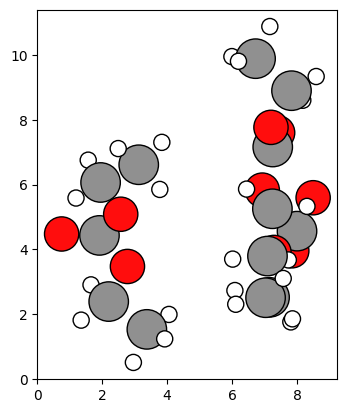

In [12]:
from ase.visualize.plot import plot_atoms

plot_atoms(db[10], radii=0.8, rotation="10x,10y,0z")  # here we're looking at the 10th configuration in the dataset

In [13]:
from ase.visualize import view

view(db[20], viewer='x3d')  # 20th frame

Let's plot the distribution of number of atoms in each configuration in the dataset:

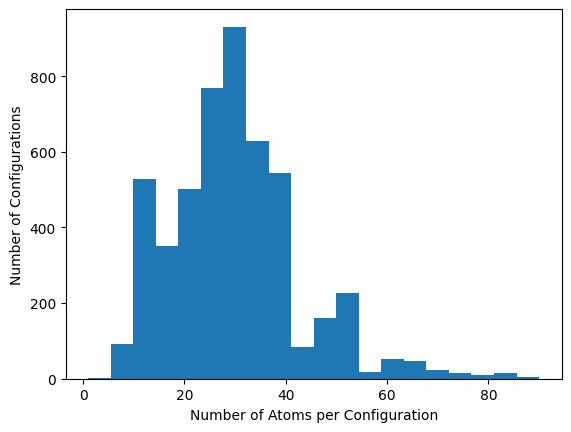

In [20]:
import matplotlib.pyplot as plt

plt.hist([len(i) for i in db], bins=20);
plt.xlabel('Number of Atoms per Configuration');
plt.ylabel('Number of Configurations');

Let's determine what elements are present and in what proportions. This will tell us what
materials/compositions we're working with:

In [24]:
# let's look at just the 10th configuration in the dataset (list) to start:
tenth_frame = db[10]
print(tenth_frame)

Atoms(symbols='CO3C3H2CH8CO3C3H2CH8COCOCH2OH2', pbc=False, forces_xtb=..., molID=...)


We can see that just printing the `Atoms` object shows us information about the configuration, including the chemical species present, the cell parameters, etc.

For instance here we see that the configuration has a chemical formula of CO3C3H2CH8CO3C3H2CH8COCOCH2OH2. Can this formula be reduced?

If we haven't used ASE before, how can we figure out what information is stored in the `Atoms` object, and how to access it?

1. Documentation – We can find online documentation for ASE, and the `Atoms` class. See for example the [ASE Atoms class documentation](https://ase-lib.org/ase/atoms.html).
    
    For reasonably popular codes, generative AI tools like ChatGPT can also give useful information, but as always we should be suspicious of the accuracy of the answers! Ask a genAI tool what the `Atoms` class is, and what information it contains.

From looking at the documentation, how can we get information about the chemical composition of the configuration?

In [25]:
tenth_frame.get_chemical_formula()  # we can use this function to get the chemical formula

'C13H24O9'

2. Docstrings – We can access the 'docstring' (short descriptions of the object/functions), using the `help` function, by looking in the Python code itself, using `<object>?` in a Jupyter notebook cell, or by other means.

In [26]:
help(tenth_frame)

Help on Atoms in module ase.atoms object:

class Atoms(_LimitedAtoms)
 |  Atoms(symbols=None, *args, calculator=None, **kwargs) -> 'None'
 |
 |  Atoms object.
 |
 |  The Atoms object can represent an isolated molecule, or a
 |  periodically repeated structure.  It has a unit cell and
 |  there may be periodic boundary conditions along any of the three
 |  unit cell axes.
 |  Information about the atoms (atomic numbers and position) is
 |  stored in ndarrays.  Optionally, there can be information about
 |  tags, momenta, masses, magnetic moments and charges.
 |
 |  In order to calculate energies, forces and stresses, a calculator
 |  object has to attached to the atoms object.
 |
 |  Parameters
 |  ----------
 |  symbols : str | list[str] | list[Atom]
 |      Chemical formula, a list of chemical symbols, or list of
 |      :class:`~ase.Atom` objects (mutually exclusive with ``numbers``).
 |
 |      - ``'H2O'``
 |      - ``'COPt12'``
 |      - ``['H', 'H', 'O']``
 |      - ``[Atom('Ne', 

In [29]:
tenth_frame?

3. `dir()` – We can use the `dir()` function to get a list of all the attributes (information) and methods (functions) of an object.

In [31]:
dir(tenth_frame)

['__add__',
 '__ase_optimizable__',
 '__class__',
 '__delattr__',
 '__delitem__',
 '__dict__',
 '__dir__',
 '__doc__',
 '__eq__',
 '__format__',
 '__ge__',
 '__getattribute__',
 '__getitem__',
 '__getstate__',
 '__gt__',
 '__hash__',
 '__iadd__',
 '__imul__',
 '__init__',
 '__init_subclass__',
 '__iter__',
 '__le__',
 '__len__',
 '__lt__',
 '__module__',
 '__mul__',
 '__ne__',
 '__new__',
 '__reduce__',
 '__reduce_ex__',
 '__repr__',
 '__setattr__',
 '__sizeof__',
 '__str__',
 '__subclasshook__',
 '__weakref__',
 '_ase_handles_dynamic_stress',
 '_calc',
 '_celldisp',
 '_cellobj',
 '_centering_as_array',
 '_constraints',
 '_display_',
 '_get_tokens_for_repr',
 '_ipython_display_',
 '_masked_rotate',
 '_pbc',
 '_repr_mimebundle_',
 'append',
 'arrays',
 'ase_objtype',
 'calc',
 'cell',
 'center',
 'constraints',
 'copy',
 'edit',
 'euler_rotate',
 'extend',
 'fromdict',
 'get_all_distances',
 'get_angle',
 'get_angles',
 'get_angular_momentum',
 'get_array',
 'get_atomic_numbers',
 'get_

Let's generate a dictionary which counts the instances of different chemical formulae in our dataset:

In [32]:
formulas = [frame.get_chemical_formula() for frame in db]  # list of chemical formulae in our dataset

formula_counts = {}
for formula in formulas:
    if formula in formula_counts:
        formula_counts[formula] += 1
    else:
        formula_counts[formula] = 1

print(formula_counts)

{'H': 1, 'C': 1, 'O': 1, 'C9H6O9': 157, 'C6H10O6': 179, 'C7H12O6': 239, 'C7H14O6': 128, 'C12H16O12': 171, 'C9H12O9': 140, 'C8H14O6': 281, 'C13H24O9': 34, 'C9H16O6': 141, 'C7H10O6': 194, 'C18H34O12': 2, 'C11H16O9': 28, 'C6H6O6': 103, 'C9H16O9': 30, 'C15H30O15': 16, 'C8H16O6': 222, 'C3H6O3': 145, 'C10H20O6': 133, 'C8H12O6': 209, 'C16H24O12': 112, 'C9H18O6': 162, 'C12H24O12': 84, 'C4H6O3': 138, 'C12H8O12': 89, 'C3H4O3': 244, 'C6H8O6': 59, 'C9H18O9': 232, 'C25H42O18': 1, 'C10H12O9': 25, 'C14H20O12': 9, 'C12H18O9': 251, 'C4H8O3': 107, 'C19H34O15': 3, 'C15H30O9': 24, 'C5H10O3': 132, 'C3H2O3': 93, 'C12H20O9': 27, 'C6H12O6': 30, 'C12H22O9': 38, 'C12H24O9': 23, 'C14H28O9': 19, 'C21H34O18': 2, 'C11H18O9': 37, 'C10H16O9': 24, 'C17H32O12': 2, 'C11H14O9': 4, 'C7H8O6': 71, 'C13H22O9': 10, 'C10H10O9': 10, 'C9H14O9': 18, 'C20H30O15': 29, 'C20H40O15': 2, 'C15H26O15': 1, 'C11H20O9': 36, 'C13H26O9': 3, 'C9H8O9': 5, 'C15H20O15': 37, 'C20H34O15': 3, 'C20H36O15': 5, 'C15H10O15': 3, 'C15H26O12': 5, 'C9H10O9'

**Note:**
ASE is a very useful tool in computational materials science. There are a number of useful tutorials available from an ASE workshop [here](https://ase-workshop-2023.github.io/tutorial/), as well as on the ASE website [here](https://ase-lib.org/examples_generated/tutorials/index.html) (including a useful one on [running MD in ASE](https://ase-lib.org/examples_generated/tutorials/md.html)).

## 2. Understanding MACE parameters

### 2.1 Model parameters

Here we have a high-level explanation of the important parameters in MACE. You can consult the [documentation](https://github.com/ACEsuit/mace) for additional parameters.

- ##### <font color='red'>--num_interactions</font>: message-passing layers

Controls the number of message-passing layers in our deep neural network model.

&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp; <font color='red'>--num_channels=32</font>

Controls the width of our neural network layers.

&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp; <font color='red'>--max_L=1</font>

Controls the level of 'equivariance' of the model; L=0 is invariant, L=1 is equivariant, L>=2 are higher levels of equivariance.

<font color='blue'>**In general, the `accuracy` of the model can be improved by using more layers, more channels or higher equivariances. This will result in more parameters and `slower` models.**</font>

- ##### <font color='red'>--correlation</font>: the order of the many-body energy expansion
$$
E_{i} = E^{(0)}_{i} + \sum_{j} E_{ij}^{(1)} + \sum_{jk} E_{ijk}^{(2)} + ...
$$

- ##### <font color='red'>--r_max</font>: the cutoff radius

The radial cut-off applied to the local atomic environment in each layer. `r_max=3.0` means atoms separated by a distance of more than 3.0 A do not directly `communicate`. When the model has multiple message-passing layers, atoms further than 3.0 A can still `communicate` through later messages if intermediate proxy atoms exist. The effective `receptive field` of the model is `num_interactions x r_max` (i.e. number of layers times the per-layer radial cutoff).

- ##### <font color='red'>--max_ell</font>: angular resolution

The angular resolution describes how well the model can describe angles. This is controlled by `l_max` of the spherical harmonics basis (not to be confused with `max_L`). Larger values will result in more accurate but slower models. The default is `l_max=3`, appropriate in most cases.

Let's train our first model:
(we write our model training parameters to a yaml file, that we then specify with the MACE training command)

We also have to specify our training data.

Let's start by splitting the data into a train and test set.

In [77]:
from ase.io import read, write

write('solvent_train_203.xyz', db[:203]) # first 203 configs
write('solvent_test.xyz', db[-1000:]) # last 1000 configs

There are some additional settings we must give in our training configuration file:

- ##### <font color='red'>--name</font>: the name of the model
This name will be used to form file names (model, log, checkpoints, results), so choose a distinct name for each experiment

- ##### <font color='red'>--model_dir, --log_dir, --checkpoints_dir, --results_dir</font>: directory paths
These are the directories where each type of file is saved. For simplicity, we will save all files in the same directory.

- ##### <font color='red'>--train_file</font>: name of training data

These data configs are used to compute gradients and update model parameters.

- ##### <font color='red'>--valid_fraction</font>: fraction of training dataset to use for validation (rather than direct model training)

- ##### <font color='red'>--test_file</font>: name of testing data

This set is entirely independent and only gets evaluated at the end of the training process to estimate the model accuracy on an independent set.

- ##### <font color='red'>--device</font> computing device to use
Can be CPU (`cpu`), GPU (`cuda`) or Apple Silicon (`mps`). Here we will use `cuda` since the GPU will be significantly faster than the CPU.

- ##### <font color='red'>--batch_size</font> number of configs evaluated in one batch
Number of configs used to compute the gradients for each full update of the network parameters. This training strategy is called stochastic gradient descent because only a subset of the data (`batch_size`) is used to change the parameters at each update.

- ##### <font color='red'>--max_num_epochs</font> number of passes through the data
An `epoch` is completed when the entire training data has been used once in updating the weights `batch` by `batch`. A new epoch begins, and the process repeats.

Now we are ready to fit our first MACE model:

## 3. Fitting and Testing MACE models

### 3.1 Fitting the model

In [78]:
%%writefile mace_train_config.yml

# model hyperparameters:
model: "MACE"
num_interactions: 2
num_channels: 32
max_L: 0
correlation: 2
r_max: 4.0
max_ell: 2

# other training settings
name: "mace01" # name for our model
train_file: "solvent_train_203.xyz"  # dataset
valid_fraction: 0.10  # fraction of dataset to use for validation
test_file: "solvent_test.xyz"  # our test dataset
device: cuda  # 'cuda' for GPU training, 'cpu' for CPU training
batch_size: 10
max_num_epochs: 50

Overwriting mace_train_config.yml


In [79]:
!mace_run_train --config mace_train_config.yml  # MACE training command
# this command prints a lot of information and many warnings (which we can ignore)

# Cleanup operataions
# remove checkpoints since they may cause errors on retraining a model with the same name but a different architecture
import glob
import os
for file in glob.glob("checkpoints/*_run-*.model"):
    os.remove(file)
for file in glob.glob("checkpoints/*.pt"):
    os.remove(file)

/usr/local/lib/python3.12/dist-packages/e3nn/o3/_wigner.py:10: UserWarning: Environment variable TORCH_FORCE_NO_WEIGHTS_ONLY_LOAD detected, since the`weights_only` argument was not explicitly passed to `torch.load`, forcing weights_only=False.
  _Jd, _W3j_flat, _W3j_indices = torch.load(os.path.join(os.path.dirname(__file__), 'constants.pt'))
cuequivariance or cuequivariance_torch is not available. Cuequivariance acceleration will be disabled.
2026-02-11 18:56:52.879 INFO: ===========VERIFYING SETTINGS===========
2026-02-11 18:56:52.880 INFO: MACE version: 0.3.14
2026-02-11 18:56:53.018 INFO: CUDA version: 12.8, CUDA device: 0
2026-02-11 18:56:53.055 INFO: ===========LOADING INPUT DATA===========
2026-02-11 18:56:53.055 INFO: Using heads: ['Default']
2026-02-11 18:56:53.055 INFO: Using the key specifications to parse data:
2026-02-11 18:56:53.055 INFO: Default: KeySpecification(info_keys={'energy': 'REF_energy', 'stress': 'REF_stress', 'virials': 'REF_virials', 'dipole': 'dipole', 'hea

What changes when increasing the `batch_size`? How about when changing the model size (`num_interactions`, `num_channels`, `max_L`, `correlation`)? Notice the accuracy vs speed trade-off.

##### <font color='purple'> **Question: Here we trained on a very small subset of the data, repeat training for 400, 1000, 2000, 4000 data points, remember to change the name of the model accordingly. How does the learning curve (test error vs size of training test) look like?** </font>

We will now use the `mace_eval_configs` script to evaluate the trained model on both the train and test datasets. The script takes the arguments: `--configs` which specifies the file to evaluate, the path to the model in `--model` and the path to the output in `--output`.

### 3.2 Testing the model: simple RMSEs

Here we'll load our trained model (into a `MACECalculator`), and use it to evaluate energies and forces on our train and test sets:

In [97]:
from mace.calculators import MACECalculator

# load our model using the MACECalculator class, which works with ASE:
calc = MACECalculator(
    model_paths=["mace01_compiled.model"],  # file path of trained model
    device="cpu",  # change to "cpu" if no CUDA GPU
    # default_dtype="float32",
)

# Evaluate on our dataset:
# let's create a dictionary to store the results for each dataset:
dataset_evaluations = {}

from tqdm import tqdm  # we can use this to show a progress bar

for dataset_name in ["train", "test"]:
    data_path = "solvent_train_203.xyz" if dataset_name == "train" else "solvent_test.xyz"
    data = read(data_path, index=":")

    # we will store the results in lists:
    dft_energies = []
    dft_forces = []
    mace_energies = []
    mace_forces = []

    for atoms in tqdm(data):  # iterate over the frames in the data
        # first collect reference DFT energies and forces:
        dft_energies.append(atoms.info["REF_energy"] / len(atoms))  # energies per atom
        dft_forces.extend(atoms.arrays["REF_forces"].flatten())  # forces per atom
        # (we use flatten() to convert the 1x3 array of x/y/z forces to a 1D array, that we can add to lists)

        # then predict energies and forces using our trained model:
        # to do this with ASE, we attach our trained model Calculator to the atoms
        # object (atoms.calc), which is then used when we call the
        # get_potential_energy() or get_forces() methods:
        atoms.calc = calc  # set the calculator to our trained model
        mace_energies.append(atoms.get_potential_energy() / len(atoms))  # energies per atom
        mace_forces.extend(atoms.get_forces().flatten())  # forces per atom

    # convert the lists to numpy arrays for easier processing, and add to dict:
    dataset_evaluations[dataset_name] = {
        "dft_energies": np.array(dft_energies),
        "dft_forces": np.array(dft_forces),
        "mace_energies": np.array(mace_energies),
        "mace_forces": np.array(mace_forces),
    }

Using head Default out of ['Default']
No dtype selected, switching to float64 to match model dtype.


100%|██████████| 1000/1000 [00:21<00:00, 45.77it/s]


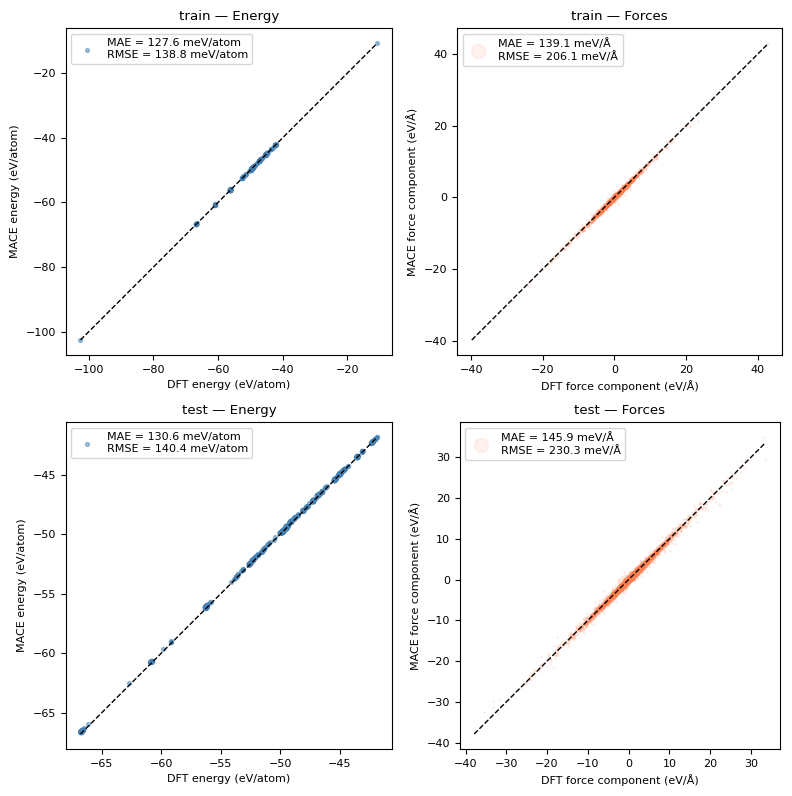

In [98]:
fig, axes = plt.subplots(2, 2, figsize=(8,8))

for i, dataset_name in enumerate(["train", "test"]):
    data = dataset_evaluations[dataset_name]
    dft_e = data["dft_energies"]
    ml_e = data["mace_energies"]
    dft_f = data["dft_forces"]
    ml_f = data["mace_forces"]

    # Energy metrics (meV/atom)
    e_mae = np.mean(np.abs(dft_e - ml_e)) * 1000
    e_rmse = np.sqrt(np.mean((dft_e - ml_e) ** 2)) * 1000

    # Force metrics (meV/Å)
    f_mae = np.mean(np.abs(dft_f - ml_f)) * 1000
    f_rmse = np.sqrt(np.mean((dft_f - ml_f) ** 2)) * 1000

    # Energy parity plot
    ax_e = axes[i, 0]
    ax_e.scatter(dft_e, ml_e, s=8, alpha=0.5, color="steelblue",
                 label=f"MAE = {e_mae:.1f} meV/atom\nRMSE = {e_rmse:.1f} meV/atom")
    lims = [min(dft_e.min(), ml_e.min()), max(dft_e.max(), ml_e.max())]
    ax_e.plot(lims, lims, "k--", linewidth=1)
    ax_e.set_xlabel("DFT energy (eV/atom)")
    ax_e.set_ylabel("MACE energy (eV/atom)")
    ax_e.set_title(f"{dataset_name} — Energy")
    ax_e.set_aspect("equal")
    ax_e.legend(fontsize=8, loc="upper left")

    # Force parity plot
    ax_f = axes[i, 1]
    # subsample forces for plotting speed
    n_pts = min(50000, len(dft_f))
    idx = np.random.choice(len(dft_f), n_pts, replace=False)
    ax_f.scatter(dft_f[idx], ml_f[idx], s=1, alpha=0.1, color="coral",
                 label=f"MAE = {f_mae:.1f} meV/Å\nRMSE = {f_rmse:.1f} meV/Å")
    flims = [dft_f.min(), dft_f.max()]
    ax_f.plot(flims, flims, "k--", linewidth=1)
    ax_f.set_xlabel("DFT force component (eV/Å)")
    ax_f.set_ylabel("MACE force component (eV/Å)")
    ax_f.set_title(f"{dataset_name} — Forces")
    ax_f.set_aspect("equal")
    ax_f.legend(fontsize=8, loc="upper left", markerscale=10)

plt.tight_layout()
plt.show()

These figures show correlation plots between the reference values and MACE predicted values for energy per atom and forces. Do the RMSE values match the number printed at the end of the model training?
These errors don't look too bad, and this MACE is a small model with few parameters. Significantly better accuracies can be achieved when training on larger models with more data. How does your model trained on 4000 configs compare?

## 4. Molecular Dynamics with MACE

### 4.1 Is the dynamics stable?

Accuracy on fixed test sets is great, but molecular dynamics (MD) is the ultimate test. First, we care about stability, then accuracy: let's check if MACE gives stable dynamics. We will start by implementing a simple function to run molecular dynamics with a Langevin thermostat. We initialize the temperature at 300 K:

In [99]:
from ase.io import read, write
from ase import units
from ase.md.langevin import Langevin
from ase.md.velocitydistribution import MaxwellBoltzmannDistribution

import random
import os
import time
import numpy as np
import pylab as pl
from IPython import display

def simpleMD(init_conf, temp, calc, fname, s, T):
    init_conf.set_calculator(calc)

    # initialize the temperature
    random.seed(701) # making sure the MD run is fully reproducible
    MaxwellBoltzmannDistribution(init_conf, temperature_K=300) #initialize temperature at 300

    # NVT Molecular dynamics with Langevin thermostat
    dyn = Langevin(init_conf, 1.0*units.fs, temperature_K=temp, friction=0.1) # drive system to desired temperature

    %matplotlib inline

    time_fs = []
    temperature = []
    energies = []

    #remove previously stored trajectory with the same name
    os.system('rm -rfv '+fname)

    fig, ax = pl.subplots(2, 1, figsize=(6,6), sharex='all', gridspec_kw={'hspace': 0, 'wspace': 0})

    def write_frame():
        dyn.atoms.write(fname, append=True)
        time_fs.append(dyn.get_time()/units.fs)
        temperature.append(dyn.atoms.get_temperature())
        energies.append(dyn.atoms.get_potential_energy()/len(dyn.atoms))

        ax[0].plot(np.array(time_fs), np.array(energies), color="b")
        ax[0].set_ylabel('E (eV/atom)')

        # plot the temperature of the system as subplots
        ax[1].plot(np.array(time_fs), temperature, color="r")
        ax[1].set_ylabel('T (K)')
        ax[1].set_xlabel('Time (fs)')

        display.clear_output(wait=True)
        display.display(pl.gcf())
        time.sleep(0.01)

    dyn.attach(write_frame, interval=s)
    t0 = time.time()
    dyn.run(T)
    t1 = time.time()
    print("MD finished in {0:.2f} minutes!".format((t1-t0)/60))

Now we can run MD with MACE. Let's try 2 picoseoncds at 1200 K, starting from a single molecule config:

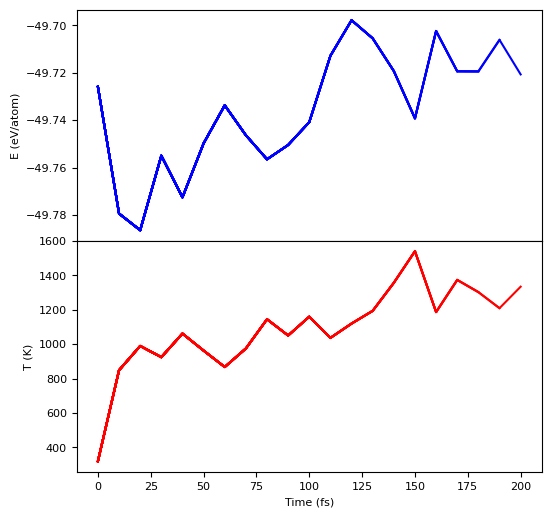

MD finished in 0.23 minutes!


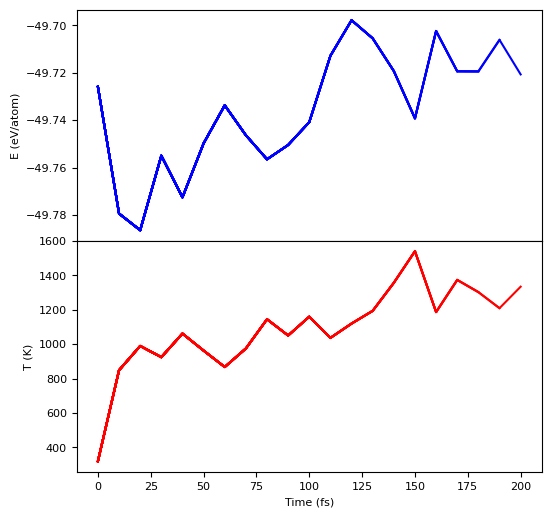

In [103]:
#we can use MACE as a calculator in ASE!
from mace.calculators import MACECalculator
mace_calc = MACECalculator(model_paths=['mace01_compiled.model'], device='cuda', default_dtype="float32")
init_conf = db[100]

simpleMD(
    init_conf,  # initial configuration for MD
    temp=1200,  # MD simulation temperature
    calc=mace_calc,  # MD calculator
    fname='mace01_md.xyz',  # output trajectory file name
    s=10,  # timestep in fs
    T=200  # num steps to run
    )


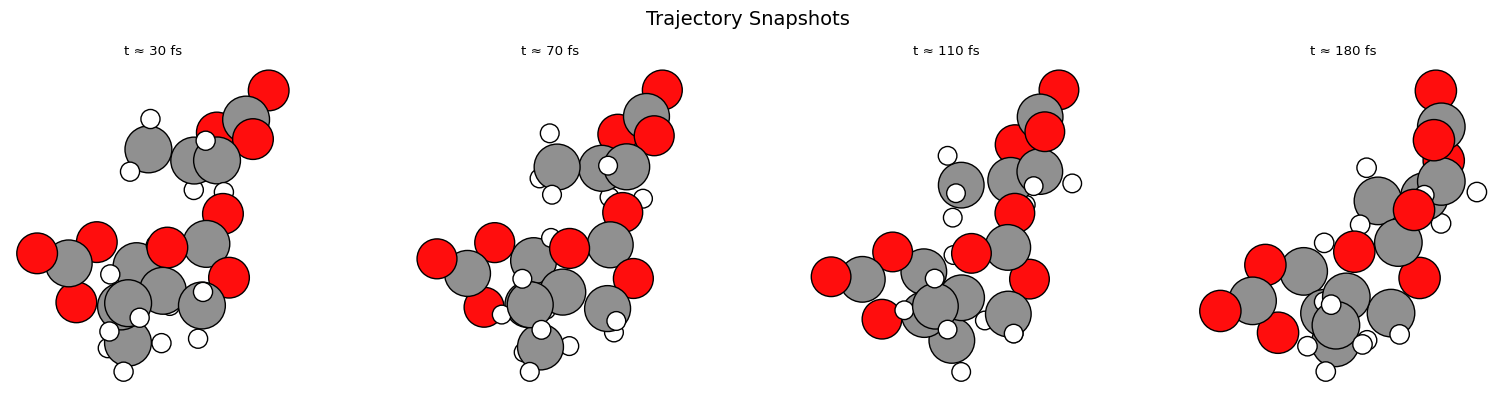

In [110]:
from ase.visualize.plot import plot_atoms

# let's generate images of a few snapshots from our trajectory:
fig, axes = plt.subplots(1, 4, figsize=(16, 4))

traj = read("mace01_md.xyz", index=":")
for i, idx in enumerate([3, 7, 11, 18]):  # snapshots at different timesteps
    plot_atoms(traj[idx], axes[i], rotation="10x,10y,0z")
    axes[i].set_title(f"t ≈ {idx*10:.0f} fs")
    axes[i].axis("off")

plt.suptitle("Trajectory Snapshots", fontsize=14)
plt.tight_layout()
plt.show()

### 4.2 Is the dynamics accurate?

Are the different dynamics sampling the correct distributions? Let us check the radial distribution functions (RDF). The [aseMolec](https://github.com/imagdau/aseMolec) package provides functionality to do that:

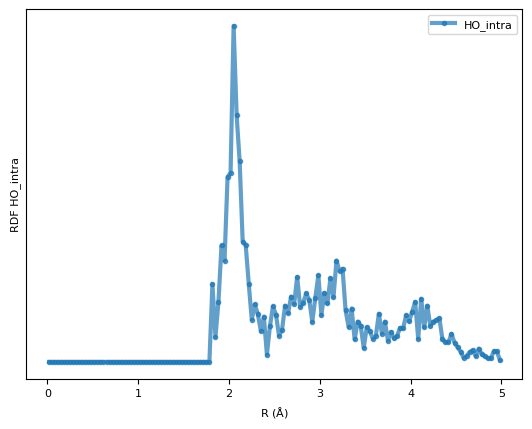

In [113]:
from aseMolec import anaAtoms as aa

tag = 'HO_intra' #choose one of 'HH_intra', 'HC_intra', 'HO_intra', 'CC_intra', 'CO_intra', 'OO_intra'

for at in traj:
    at.pbc = True #create a fake box for rdf compatibility
    at.cell = [100,100,100]
rdf = aa.compute_rdfs_traj_avg(traj, rmax=5, nbins=150) #aseMolec provides functionality to compute RDFs
plt.plot(rdf[1], rdf[0][tag], '.-', label=tag, alpha=0.7, linewidth=3)

plt.legend();
plt.yticks([]);
plt.xlabel(r'R ($\rm \AA$)');
plt.ylabel('RDF '+tag);

Try it yourself! Inspect other RDF pairs (`C-O`, `H-C`), how well are they reproduced?

The RDF here looks a bit jagged, but we know in reality it should be quite smooth. Why is this? What can we do to get a smoother RDF here?

The trajectories here are mostly stable, though this is still a relatively simple task.

Experiment with the starting configs, temperatures, simulation length, see if you can find problems with the potentials!

## Extensions
- How can we make our model more accurate here? See if you can change parameters / setup to decrease errors and improve accuracy!
- See if you can cause the MD simulation to explode by changing parameters like temperature, initial configuration setup etc!